In [1]:
import sys
sys.path.append("../")

import pandas as pd
import numpy as np

df = pd.read_csv("../data/processed/credit_data_clean.csv")

df.head()

,status,duration,credit_history,purpose,amount,savings,employment_duration,installment_rate,personal_status_sex,other_debtors,...,age,other_installment_plans,housing,number_credits,job,people_liable,telephone,foreign_worker,credit_risk,default
0,... < 100 DM,6,critical account/other credits existing,domestic appliances,1169,unknown/no savings account,... >= 7 years,4,male : single,none,...,67,none,own,2,skilled employee/official,1,yes,yes,1,1
1,0 <= ... < 200 DM,48,existing credits paid back duly till now,domestic appliances,5951,... < 100 DM,1 <= ... < 4 years,2,female : divorced/separated/married,none,...,22,none,own,1,skilled employee/official,1,no,yes,0,0
2,no checking account,12,critical account/other credits existing,retraining,2096,... < 100 DM,4 <= ... < 7 years,2,male : single,none,...,49,none,own,1,unskilled - resident,2,no,yes,1,1
3,... < 100 DM,42,existing credits paid back duly till now,radio/television,7882,... < 100 DM,4 <= ... < 7 years,2,male : single,guarantor,...,45,none,for free,1,skilled employee/official,2,no,yes,1,1
4,... < 100 DM,24,delay in paying off in the past,car (new),4870,... < 100 DM,1 <= ... < 4 years,3,male : single,none,...,53,none,for free,2,skilled employee/official,2,no,yes,0,0


In [2]:
# 1️⃣ Loan burden ratio
df['amount_duration_ratio'] = df['amount'] / df['duration']

# 2️⃣ Age bucket
df['age_bucket'] = pd.cut(df['age'],
                          bins=[18, 30, 45, 60, 100],
                          labels=['18-30', '31-45', '46-60', '60+'])

# 3️⃣ Log of loan amount (reduce skew)
df['log_amount'] = np.log(df['amount'])

# 4️⃣ Duration squared (non-linear effect)
df['duration_squared'] = df['duration'] ** 2

# 5️⃣ Installment burden indicator
df['high_installment'] = (df['installment_rate'] >= 3).astype(int)

# 6️⃣ Credit per person liability
df['amount_per_person'] = df['amount'] / df['people_liable']

# 7️⃣ Senior risk flag
df['senior_flag'] = (df['age'] > 60).astype(int)

# 8️⃣ Young applicant flag
df['young_flag'] = (df['age'] < 25).astype(int)

# 9️⃣ Multiple credits flag
df['multiple_credits'] = (df['number_credits'] > 1).astype(int)

# 🔟 Long duration flag
df['long_duration'] = (df['duration'] > df['duration'].median()).astype(int)

df.head()

,status,duration,credit_history,purpose,amount,savings,employment_duration,installment_rate,personal_status_sex,other_debtors,...,amount_duration_ratio,age_bucket,log_amount,duration_squared,high_installment,amount_per_person,senior_flag,young_flag,multiple_credits,long_duration
0,... < 100 DM,6,critical account/other credits existing,domestic appliances,1169,unknown/no savings account,... >= 7 years,4,male : single,none,...,194.833333,60+,7.063904,36,1,1169.0,1,0,1,0
1,0 <= ... < 200 DM,48,existing credits paid back duly till now,domestic appliances,5951,... < 100 DM,1 <= ... < 4 years,2,female : divorced/separated/married,none,...,123.979167,18-30,8.691315,2304,0,5951.0,0,1,0,1
2,no checking account,12,critical account/other credits existing,retraining,2096,... < 100 DM,4 <= ... < 7 years,2,male : single,none,...,174.666667,46-60,7.647786,144,0,1048.0,0,0,0,0
3,... < 100 DM,42,existing credits paid back duly till now,radio/television,7882,... < 100 DM,4 <= ... < 7 years,2,male : single,guarantor,...,187.666667,31-45,8.972337,1764,0,3941.0,0,0,0,1
4,... < 100 DM,24,delay in paying off in the past,car (new),4870,... < 100 DM,1 <= ... < 4 years,3,male : single,none,...,202.916667,46-60,8.490849,576,1,2435.0,0,0,1,1


### Engineered Feature Rationale

1. amount_duration_ratio → Measures loan burden intensity.
2. age_bucket → Captures lifecycle risk segmentation.
3. log_amount → Reduces skewness in loan size.
4. duration_squared → Captures non-linear repayment risk.
5. high_installment → Identifies high repayment pressure.
6. amount_per_person → Measures liability concentration.
7. senior_flag → Captures retirement-age risk.
8. young_flag → Captures early-career instability.
9. multiple_credits → Indicates higher financial leverage.
10. long_duration → Identifies long-term exposure risk.

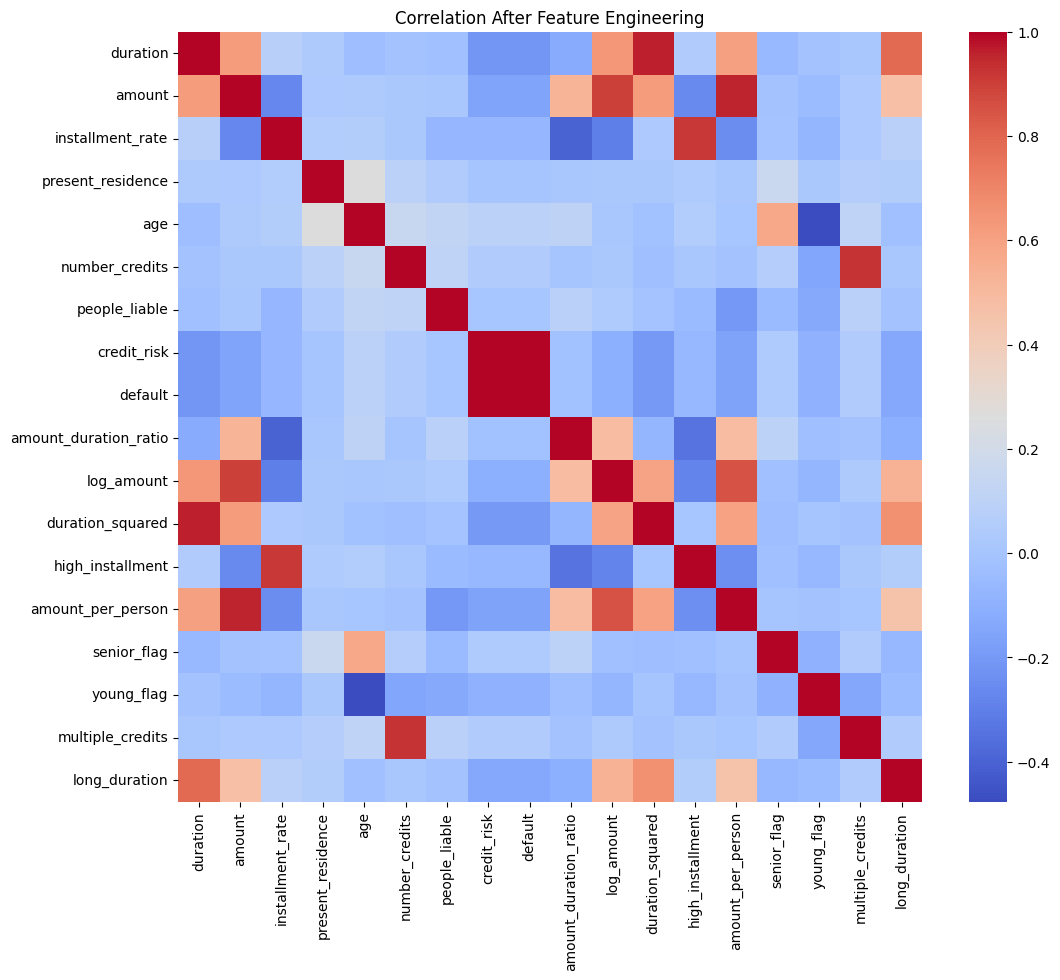

In [3]:
import seaborn as sns
import matplotlib.pyplot as plt

numeric_df = df.select_dtypes(include=['int64', 'float64'])

plt.figure(figsize=(12,10))
sns.heatmap(numeric_df.corr(), cmap="coolwarm")
plt.title("Correlation After Feature Engineering")
plt.show()

In [5]:
from sklearn.feature_selection import SelectKBest, f_classif

X = numeric_df.drop(columns=['default', 'credit_risk'])
y = numeric_df['default']

selector = SelectKBest(score_func=f_classif, k=10)
selector.fit(X, y)

selected_features = X.columns[selector.get_support()]

selected_features

Index(['duration', 'amount', 'installment_rate', 'age', 'log_amount',
       'duration_squared', 'high_installment', 'amount_per_person',
       'young_flag', 'long_duration'],
      dtype='str')

### Feature Selection Strategy

ANOVA F-test was used to identify the most predictive numeric variables.
Top 10 statistically significant predictors were selected.
This prevents overfitting and improves model interpretability.

In [8]:
df.to_csv("../data/processed/credit_data_engineered.csv", index=False)

print("Engineered dataset saved successfully!")

Engineered dataset saved successfully!


### Fairness Consideration

Sensitive demographic proxies such as gender, marital status, and housing
were reviewed carefully. Feature engineering avoided directly encoding
protected characteristics to ensure compliance with fair lending principles.